In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_style("whitegrid")

df = pd.read_csv('Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['FamilySize'] = df['SibSp'] + df['Parch']

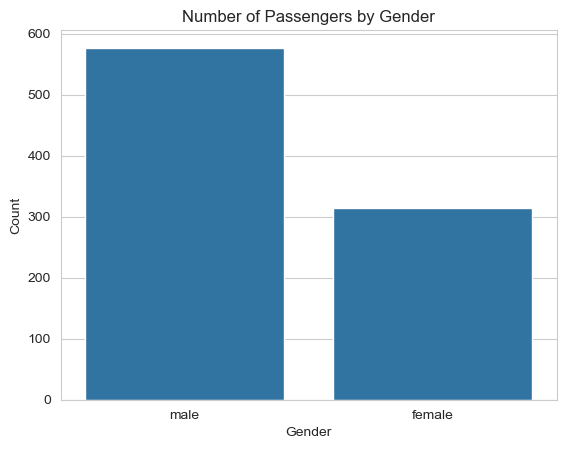

In [5]:
#Q1

sns.countplot(data=df, x='Sex')
plt.title('Number of Passengers by Gender')
plt.xlabel('Gender'); plt.ylabel('Count')
plt.show()

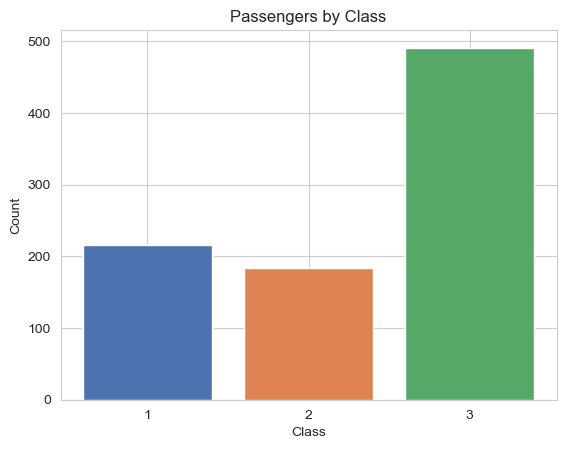

In [6]:
#Q2

class_counts = df['Pclass'].value_counts().sort_index()
plt.bar(class_counts.index.astype(str), class_counts.values, color=['#4C72B0','#DD8452','#55A868'])
plt.title('Passengers by Class'); plt.xlabel('Class'); plt.ylabel('Count')
plt.show()

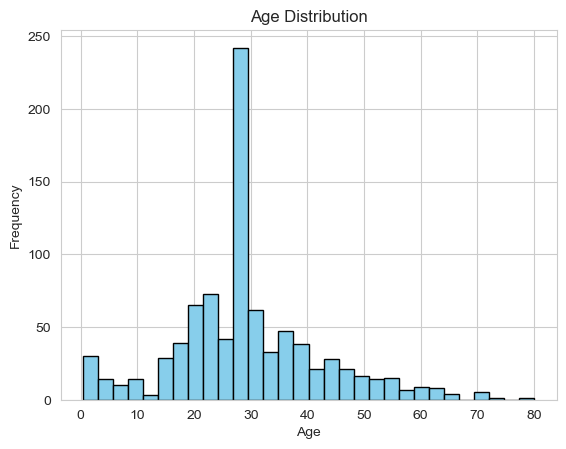

In [10]:
#Q3

plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution'); plt.xlabel('Age'); plt.ylabel('Frequency')
plt.show()

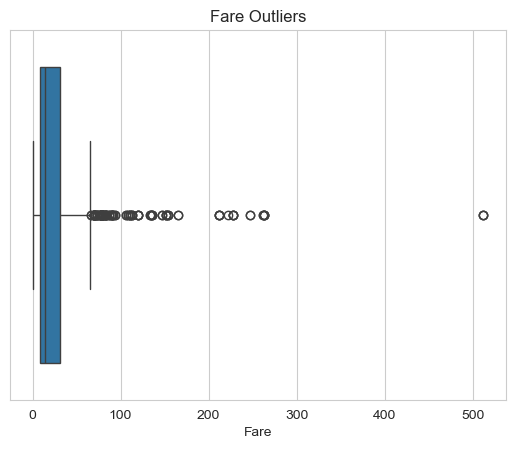

In [11]:
#Q4

sns.boxplot(x=df['Fare'])
plt.title('Fare Outliers'); plt.xlabel('Fare')
plt.show()

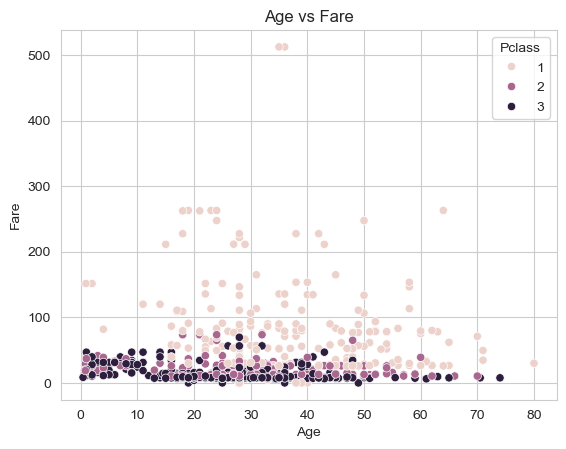

In [12]:
#Q5

sns.scatterplot(data=df, x='Age', y='Fare', hue='Pclass')
plt.title('Age vs Fare')
plt.show()

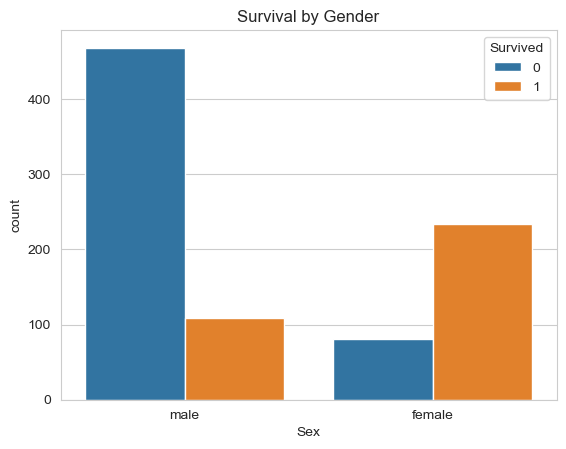

In [13]:
#Q6

sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by Gender')
plt.show()

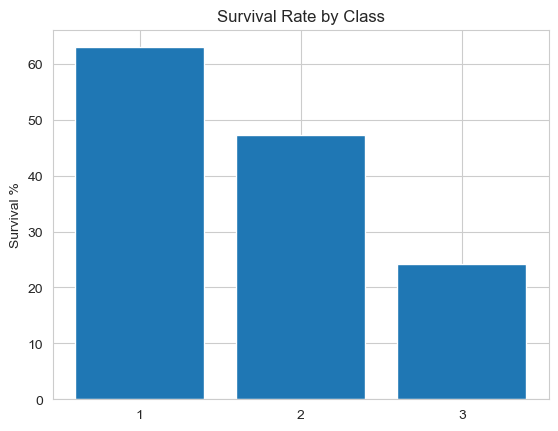

In [14]:
#Q7
survival_by_class = df.groupby('Pclass')['Survived'].mean()*100
plt.bar(survival_by_class.index.astype(str), survival_by_class.values)
plt.title('Survival Rate by Class'); plt.ylabel('Survival %')
plt.show()

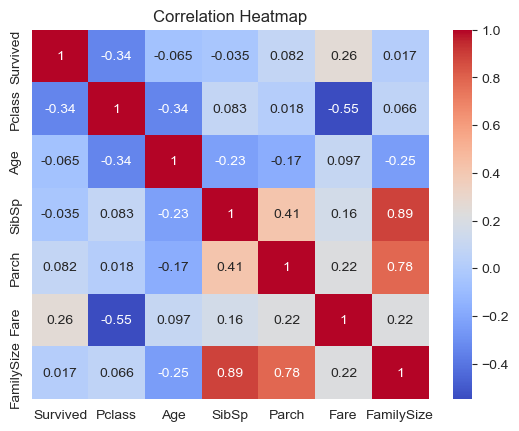

In [17]:
#Q8

numeric_cols = ['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [18]:
#Q9

avg_fare = df.groupby('Pclass')['Fare'].mean().sort_values(ascending=False)
print(avg_fare)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64
